# 036 — GM record selection, AvgSA([0, 6]) — Stage 2 (post-processing)

Loads the canonical `AvgSA_06_final_ensembles.pickle` produced by the Stage-1 compute notebook
(`035-gm_selection_AvgSA_06_stage1_compute.ipynb`) and regenerates the result pickles, plots and
download/convert CSVs. Runs in seconds; it never triggers the hour-long selection. Before doing
any work it calls `cache_utils.verify(...)` on the artifact's source-file fingerprint — if those
inputs changed since Stage-1 wrote the pickle, a `StaleCacheError` is raised and you must rebuild
via `035`.

**Upstream**:
- `AvgSA_06_final_ensembles.pickle` (+ manifest) — from nb `035`.
- `gcim_dist_AvgSA_06.pickle` (nb `034`) — for the per-ensemble `gcim_quantiles`.
- Disagg data/stats — `cfg["proc_data"]["AvgSA_06_disagg_data_gm_selection"]`,
  `cfg["proc_data"]["AvgSA_06_disagg_stats_gm_selection"]` (hashed for the staleness check).

**Output**:
- Per-`(site, iml)` ensemble pickles `site_{id}__stripe_iml_{iml}__gm_selection.pickle` in
  `cfg["results"]["AvgSA_06_record_selection"]` — enriched with `poe`/`rtp`, `gcim_quantiles`,
  `trt_stats`, and per-record `RSN`/`record_identifier`/`filename`. The iml token is zero-padded /
  `pt`-encoded (e.g. `01pt150`); `standes` orders stripes by parsing it back to a float. Consumed
  downstream by the `standes` MSA stripe reader.
- Record-download summaries: `AvgSA_06_summary_esm_records_selected.csv`,
  `AvgSA_06_summary_ngasub_records_selected.csv`.
- `AvgSA_06_records_to_convert.csv` — the AT2/HDF5→JSON conversion list (combined across
  campaigns in `040-organise_records_to_download.ipynb`).

**Run order** — run top to bottom after `035` has produced the final-ensembles artifact. Fast
(seconds); safe to re-run.

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from phd_project.config.config import load_config
from phd_project.scripts.cache_utils import fingerprint, verify, write_manifest
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    get_poe_from_disaggstats, iml_filename_tag,
    stripe_input_fingerprint, stripe_pickle_path, find_stale_stripes)
from phd_project.scripts.WP1_ground_motion_set.setup_AvgSA06_gm_selection import (
    setup_AvgSA06_gcim_gm_selection, SELECTION_CONFIG, stripe_source_fps)

cfg = load_config()

# paths
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / "gcim_dist_AvgSA_06.pickle"
final_ensembles_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_06_final_ensembles.pickle"
esm_records_to_download_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_06_summary_esm_records_selected.csv"
ngasub_records_to_download_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_06_summary_ngasub_records_selected.csv"
records_to_convert_fp = cfg["proc_data"]["gm_selection"] / "AvgSA_06_records_to_convert.csv"
disagg_stats_fp = cfg["proc_data"]["AvgSA_06_disagg_stats_gm_selection"]
disagg_data_fp = cfg["proc_data"]["AvgSA_06_disagg_data_gm_selection"]
RESULT_FOLDER = cfg["results"]["AvgSA_06_record_selection"]

# The selection context (for the per-stripe fingerprint) and the full wanted key set
# (for orphan pruning + cross-site aggregation) come from setup. disagg_stats is also
# returned here (used for the poe metadata below).
site_iml_disaggs, disagg_stats, site_model, basic_selection_ctx, _ = setup_AvgSA06_gcim_gm_selection()
wanted = list(site_iml_disaggs.keys())
source_fps_stripe = stripe_source_fps()
fp_fn = lambda s, i: stripe_input_fingerprint(
    s, i, source_fps_stripe, basic_selection_ctx, SELECTION_CONFIG)

# load the batch that nb 035 just (re)selected, plus its gcim (both per-batch scratch)
with open(final_ensembles_fp, "rb") as f:
    final_ensembles = pickle.load(f)
with open(gcim_dist_fp, "rb") as f:
    gcim_dists = pickle.load(f)

# Refuse to post-process a stale batch artifact: confirm the source files that produced
# final_ensembles are unchanged (hashes only -- nothing heavy is loaded).
verify(final_ensembles_fp, fingerprint(
    gm_db_file=cfg["proc_data"]["gm_database"],
    gcim_file=gcim_dist_fp,
    disagg_data_file=disagg_data_fp,
    disagg_stats_file=disagg_stats_fp,
    site_model_file=cfg["hazard_models"]["eshm20_wp1_site_model"],
))
print("Batch artifact provenance verified.")

# Provenance stamp for the download/convert CSVs written below.
csv_provenance = fingerprint(final_ensembles=final_ensembles_fp)

## Save per-(site, iml) ensembles + surface record identifiers

In [ ]:
# Save the (re)selected stripes into the results folder. Each stripe pickle carries a
# .manifest.json (its per-stripe fingerprint) which IS the incremental cache: a stripe
# whose manifest already matches is left untouched. We write exactly the batch nb 035
# produced (final_ensembles); writing the manifest is what marks a stripe "valid".
DISAGG_IMT = "AvgSA"  # conditioning IM name used to look up the poe metadata

_, valid_before = find_stale_stripes(wanted, RESULT_FOLDER, fp_fn)
print(f"{len(valid_before)} stripe(s) already valid on disk; writing {len(final_ensembles)} "
      f"from this batch.")

for (site, iml), ensemble in final_ensembles.items():
    if ensemble is None or not ensemble["ks_passed"]:
        print(f"No valid ensemble: Site {site} - iml = {iml}")
        continue

    # Stripe identifiers required by standes.analysis.msa.read_stripe_selection.
    # poe is 1:1 with iml per site; derive it from the disagg stats (metadata only).
    poe = get_poe_from_disaggstats(disagg_stats, site, DISAGG_IMT, iml)
    ensemble["poe"] = float(poe)
    # annual PoE -> return period via the Poisson/exponential model:
    # poe = 1 - exp(-1/rtp)  =>  rtp = -1 / ln(1 - poe)
    ensemble["rtp"] = round(-1.0 / np.log(1.0 - poe))

    # Add the gcim_quantiles from the result
    ensemble["gcim_quantiles"] = gcim_dists[(site, iml)]["stats"]

    # calculate the trt %'s
    trt_stats = pd.DataFrame(
        ensemble["recs"].groupby(("metadata", "trt")).size())
    trt_stats.columns = ["count"]
    trt_stats["proportions"] = np.round(trt_stats["count"] / \
                                        trt_stats["count"].sum(), 3)
    ensemble["trt_stats"] = trt_stats

    # Surface RSN + a stable record identifier and JSON filename per record.
    recs = ensemble["recs"]
    is_ngasub = recs[("metadata", "database")] == "NGASub"

    # RSN: already present as metadata.index for NGASub; NA for ESM.
    recs[("metadata", "RSN")] = (
        recs[("metadata", "index")].astype("string").where(is_ngasub)
    )

    # record_identifier: ESM uses event/station/location; NGASub uses the RSN.
    esm_id = (
        recs[("metadata", "event_id")].astype(str) + "_"
        + recs[("metadata", "station_code")].astype(str) + "_"
        + recs[("metadata", "location_code")].astype(str)
    )
    recs[("metadata", "record_identifier")] = esm_id.where(
        ~is_ngasub, recs[("metadata", "index")].astype(str)
    )

    # filename: {record_identifier}__{component}.json
    recs[("metadata", "filename")] = (
        recs[("metadata", "record_identifier")].astype(str)
        + "__" + recs[("metadata", "component")].astype(str) + ".json"
    )

    stripe_fp = stripe_pickle_path(RESULT_FOLDER, site, iml)
    with open(stripe_fp, "wb") as file:
        pickle.dump(ensemble, file)
    # The manifest is what makes this stripe "valid" on the next run.
    write_manifest(stripe_fp, fp_fn(site, iml))

# Prune orphans: stripe files whose (site, iml) is no longer wanted (e.g. an IML was
# removed from the union lists). This replaces the old blanket delete-all, which would
# have wiped the incremental cache.
wanted_names = {stripe_pickle_path(RESULT_FOLDER, s, i).name for (s, i) in wanted}
for old in RESULT_FOLDER.glob("*__stripe_*__gm_selection.pickle"):
    if old.name not in wanted_names:
        old.unlink()
        old.with_name(old.name + ".manifest.json").unlink(missing_ok=True)
        print(f"Pruned orphan stripe: {old.name}")

## Identify the number of unique records and unique events across all sites

In [ ]:
# combine ALL stripes on disk into one dataframe (the whole record set, not just the
# incremental batch) so the summaries / download CSVs below cover every selected stripe.
rec_dfs = []
for p in sorted(RESULT_FOLDER.glob("*__stripe_iml_*__gm_selection.pickle")):
    with open(p, "rb") as f:
        rec_dfs.append(pickle.load(f)["recs"])

all_recs = pd.concat(rec_dfs, axis=0)
events = all_recs.groupby(("metadata", "event_id")).size().sort_values(ascending=False)
events = pd.DataFrame(events, columns=["count"])
events["cum_sum"] = events["count"].cumsum() 
events["cum_%"] = np.round(events["cum_sum"] / events["count"].sum(), 4)

recs_and_events = all_recs.reset_index().groupby([("metadata", "event_id"), "index"])\
    .size().sort_values(ascending=False)
recs_and_events = pd.DataFrame(recs_and_events, columns=["count"])
recs_and_events["cum_sum"] = recs_and_events["count"].cumsum() 
recs_and_events["cum_%"] = np.round(recs_and_events["cum_sum"] / recs_and_events["count"].sum() * 100, 4)
recs_and_events

print(f"Number of unique events: {len(events)}")
print(f"Number of unique records: {len(recs_and_events)}")
print(f"Maximum number of times a record was selected: {recs_and_events["count"].iloc[0]} ({recs_and_events["count"].iloc[0] / len(all_recs)*100:.2f} %)")

In [16]:
recs_and_events

,,count,cum_sum,cum_%
"(metadata, event_id)",index,,,
IT-2012-0011,36898,177,177,1.8043
TK-1999-0415,40095,157,334,3.4047
EMSC-20160824_0000006,27532,137,471,4.8012
EMSC-20161026_0000095,29670,122,593,6.0449
EMSC-20160824_0000006,7130,120,713,7.2681
...,...,...,...,...
TK-2005-0090,20114,1,9806,99.9592
TK-2005-0054,20098,1,9807,99.9694
1000006,40781,1,9808,99.9796


(0.0, 235.2)

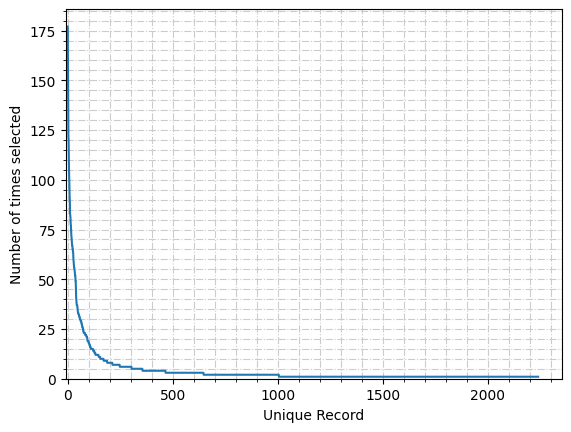

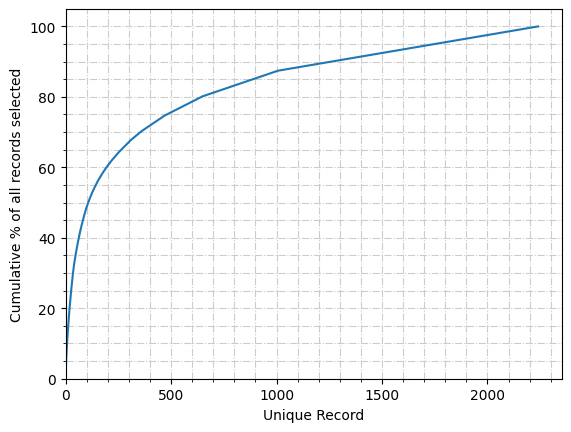

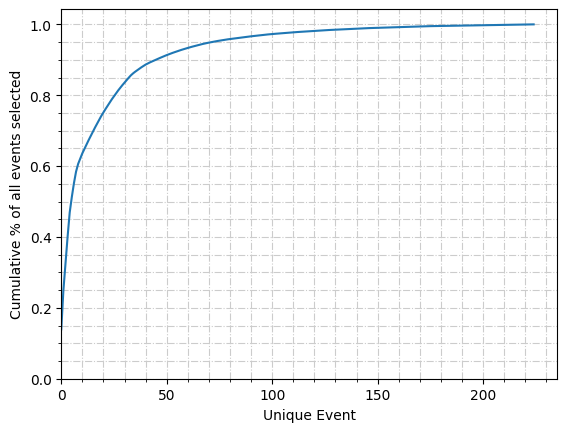

In [17]:
fig, ax3 = plt.subplots()
ax3.plot(recs_and_events["count"].to_numpy())
ax3.grid(True, which="both", ls="-.", color="0.8")
ax3.minorticks_on()
ax3.set_xlabel("Unique Record")
ax3.set_ylabel("Number of times selected")
ax3.set_ylim(0)
ax3.set_xlim(-10)

fig, ax1 = plt.subplots()
ax1.plot(recs_and_events["cum_%"].to_numpy())
ax1.grid(True, which="both", ls="-.", color="0.8")
ax1.minorticks_on()
ax1.set_xlabel("Unique Record")
ax1.set_ylabel("Cumulative % of all records selected")
ax1.set_ylim(0)
ax1.set_xlim(0)

fig, ax2 = plt.subplots()
ax2.plot(events["cum_%"].to_numpy())
ax2.grid(True, which="both", ls="-.", color="0.8")
ax2.minorticks_on()
ax2.set_xlabel("Unique Event")
ax2.set_ylabel("Cumulative % of all events selected")
ax2.set_ylim(0)
ax2.set_xlim(0)


## Records to download / convert

In [18]:
cols_to_keep = [("metadata", "event_id"), ("metadata", "station_code"), ("metadata", "location_code")]
unique_esm_records = all_recs[all_recs[("metadata", "database")] == "ESM"]\
                     .drop_duplicates(subset=cols_to_keep)
unique_esm_records = unique_esm_records[cols_to_keep].reset_index(drop=True)
esm_records_to_download = unique_esm_records
esm_records_to_download.to_csv(esm_records_to_download_fp, index=False)
write_manifest(esm_records_to_download_fp, csv_provenance)

WindowsPath('C:/Users/clemettn/Documents/phd/data_processed/06_gm_selection/AvgSA_06_summary_esm_records_selected.csv.manifest.json')

In [19]:
# For the NGASub records we need the NGAsubRSN for each combination of event_id and station_code
NGASub_records = all_recs[all_recs[("metadata", "database")] == "NGASub"]
unique_NGASub_id_counts = NGASub_records.groupby(
    [("metadata", "event_id"), ("metadata", "station_code")]).size().sort_values(ascending=False)
unique_NGASub_id_counts = unique_NGASub_id_counts.rename("count")

# load the NGASub database
ngasub_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_Metadata_SA_rotD50.csv"
ngasub_db = pd.read_csv(ngasub_fp, header=0, encoding="cp1252", dtype=str)
new_index = list(ngasub_db[["NGAsubEQID", "NGAsubSSN"]].itertuples(index=False, name=None))
ngasub_db.index = new_index
ngasub_db = ngasub_db["NGAsubRSN"]

# RSNs to download
rsns_to_download = ngasub_db.loc[unique_NGASub_id_counts.index]
rsns_to_download = pd.concat([rsns_to_download, unique_NGASub_id_counts], axis=1)
rsns_to_download.to_csv(ngasub_records_to_download_fp, index=False)
write_manifest(ngasub_records_to_download_fp, csv_provenance)

WindowsPath('C:/Users/clemettn/Documents/phd/data_processed/06_gm_selection/AvgSA_06_summary_ngasub_records_selected.csv.manifest.json')

In [20]:
# Per-campaign record-conversion list (record_identifier, component, database)
# for the AT2/HDF5 -> JSON converters. Combined across campaigns in
# wp1pt3pt8i-organise_records_to_download.
records_to_convert = (
    all_recs["metadata"][["record_identifier", "component", "database"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
records_to_convert.to_csv(records_to_convert_fp, index=False)
write_manifest(records_to_convert_fp, csv_provenance)

WindowsPath('C:/Users/clemettn/Documents/phd/data_processed/06_gm_selection/AvgSA_06_records_to_convert.csv.manifest.json')